# Step 6 - Machine Learning Pipeline (Classification)

Goal:
- Load Gold feature table from Delta Lake.
- Train 5 Spark ML classifiers.
- Compare models with Accuracy, F1, Precision, Recall, AUC-ROC.
- Track all experiments with MLflow.
- Export model outputs for Step 7 dashboard.

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "pyspark": "pyspark",
    "delta": "delta-spark",
    "mlflow": "mlflow",
    "sklearn": "scikit-learn"
}

missing_packages = [
    package_name
    for module_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print(f"Installing missing packages: {missing_packages}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
    print("Package installation completed.")
else:
    print("All Step 6 packages are already installed.")

All Step 6 packages are already installed.


In [2]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import mlflow
import mlflow.spark

from sklearn.metrics import roc_curve

from pyspark import SparkContext
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, NumericType
from pyspark.ml.classification import (
    DecisionTreeClassifier,
    GBTClassifier,
    LinearSVC,
    LogisticRegression,
    RandomForestClassifier,
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.feature import VectorAssembler

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")
sns.set_palette("tab10")

In [3]:
APP_NAME = "CreditRisk-Step6-MLPipeline"
DEFAULT_WORKSPACE_ROOT = "c:/Users/MONSTER/Desktop/fintech-credit-risk-engine-main"
ALLOW_PARQUET_FALLBACK = os.getenv("STEP6_ALLOW_PARQUET_FALLBACK", "0") == "1"
ENABLE_WINDOWS_HADOOP_HOME = os.getenv("STEP6_ENABLE_WINDOWS_HADOOP_HOME", "0") == "1"

def resolve_workspace_root(default_root: str) -> str:
    candidates = [
        os.getenv("WORKSPACE_ROOT"),
        os.getcwd(),
        default_root,
    ]
    for candidate in candidates:
        if not candidate:
            continue
        candidate = candidate.replace("\\", "/")
        if os.path.isdir(candidate) and os.path.isdir(f"{candidate}/notebooks"):
            return candidate
    return default_root

WORKSPACE_ROOT = resolve_workspace_root(DEFAULT_WORKSPACE_ROOT)
SPARK_LOCAL_DIR = os.getenv("SPARK_LOCAL_DIR", f"{WORKSPACE_ROOT}/tmp/spark-local")
os.makedirs(SPARK_LOCAL_DIR, exist_ok=True)

def ensure_windows_hadoop_home(workspace_root: str):
    if os.name != "nt" or not ENABLE_WINDOWS_HADOOP_HOME:
        return None

    candidate_homes = []
    env_home = os.environ.get("HADOOP_HOME") or os.environ.get("hadoop.home.dir")
    if env_home:
        candidate_homes.append(env_home)
    candidate_homes.append(f"{workspace_root}/third_party/hadoop")

    for home in candidate_homes:
        if not home:
            continue
        winutils_path = os.path.join(home, "bin", "winutils.exe")
        if os.path.exists(winutils_path):
            os.environ["HADOOP_HOME"] = home
            os.environ["hadoop.home.dir"] = home
            os.environ["PATH"] = os.path.join(home, "bin") + ";" + os.environ.get("PATH", "")
            return home

    return None

def reset_pyspark_runtime_state():
    try:
        SparkContext._active_spark_context = None
        SparkContext._gateway = None
        SparkContext._jvm = None
    except Exception:
        pass
    try:
        SparkSession._instantiatedSession = None
        SparkSession._activeSession = None
    except Exception:
        pass

def resolve_delta_base(workspace_root: str) -> str:
    candidates = []
    env_base = os.getenv("DELTA_BASE")
    if env_base:
        candidates.append(env_base)
    candidates.extend([
        f"{workspace_root}/delta_lake",
        "/app/delta_lake",
    ])

    for candidate in candidates:
        if candidate and os.path.exists(candidate):
            return candidate.replace("\\", "/")

    return candidates[0].replace("\\", "/")

hadoop_home = ensure_windows_hadoop_home(WORKSPACE_ROOT)
if hadoop_home:
    print(f"Using HADOOP_HOME: {hadoop_home}")
elif os.name == "nt" and not ENABLE_WINDOWS_HADOOP_HOME:
    print("HADOOP_HOME setup skipped on Windows (STEP6_ENABLE_WINDOWS_HADOOP_HOME=0).")

try:
    from delta import configure_spark_with_delta_pip
except Exception as delta_import_error:
    raise RuntimeError(
        "delta-spark import failed. Install delta-spark and rerun Step 6."
    ) from delta_import_error

reset_pyspark_runtime_state()
spark_builder = (
    SparkSession.builder
    .master("local[*]")
    .appName(APP_NAME)
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.shuffle.partitions", os.getenv("SPARK_LOCAL_SHUFFLE_PARTITIONS", "32"))
    .config("spark.default.parallelism", os.getenv("SPARK_LOCAL_DEFAULT_PARALLELISM", "32"))
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .config("spark.sql.ansi.enabled", "false")
    .config("spark.driver.memory", os.getenv("SPARK_LOCAL_DRIVER_MEMORY", "6g"))
    .config("spark.driver.maxResultSize", os.getenv("SPARK_LOCAL_DRIVER_MAX_RESULT", "1g"))
    .config("spark.local.dir", SPARK_LOCAL_DIR)
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
)

spark = configure_spark_with_delta_pip(spark_builder).getOrCreate()
spark.sparkContext.setLogLevel("WARN")

DELTA_BASE = resolve_delta_base(WORKSPACE_ROOT)
FEATURE_PATH = f"{DELTA_BASE}/gold/features"
PARQUET_FALLBACK_PATH = f"{DELTA_BASE}/gold/features_parquet_fallback"

print(f"Workspace root: {WORKSPACE_ROOT}")
print(f"Delta base: {DELTA_BASE}")
print(f"Feature path: {FEATURE_PATH}")

:: loading settings :: url = jar:file:/usr/local/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-ae723bfa-5689-462b-ac86-8229455f00d3;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central


	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 275ms :: artifacts dl 16ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   |   0   |   0   ||   3   |   0   |
	---------------------------------------------------------------------
:: retrieving :: org.apache.spark#spark-submit-parent-ae723bfa-5689-462b-ac86-8229455f00d3
	confs: [default]
	0 artifacts copied, 3 already retrieved (0kB/13ms)


26/05/13 09:45:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/05/13 09:45:28 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


26/05/13 09:45:29 WARN Utils: The configured local directories are not expected to be URIs; however, got suspicious values [c:/Users/MONSTER/Desktop/fintech-credit-risk-engine-main/tmp/spark-local]. Please check your configured local directories.


Workspace root: c:/Users/MONSTER/Desktop/fintech-credit-risk-engine-main
Delta base: /app/delta_lake
Feature path: /app/delta_lake/gold/features


In [4]:
read_errors = []

df = None
source_format = None

try:
    df = spark.read.format("delta").load(FEATURE_PATH)
    source_format = "delta"
except Exception as delta_read_error:
    read_errors.append(f"delta:{delta_read_error}")

if df is None:
    parquet_candidates = [FEATURE_PATH]
    if ALLOW_PARQUET_FALLBACK:
        parquet_candidates.append(PARQUET_FALLBACK_PATH)

    for parquet_path in parquet_candidates:
        if not os.path.exists(parquet_path):
            continue
        try:
            df = spark.read.parquet(parquet_path)
            source_format = f"parquet:{parquet_path}"
            break
        except Exception as parquet_read_error:
            read_errors.append(f"parquet:{parquet_path}:{parquet_read_error}")

if df is None:
    raise RuntimeError(
        "Step 6 could not load features from delta/parquet. "
        f"Checked paths: {[FEATURE_PATH, PARQUET_FALLBACK_PATH]}. "
        f"Errors: {read_errors}"
    )

if "target" in df.columns and "label" not in df.columns:
    df = df.withColumn("label", F.col("target").cast("double"))
elif "label" in df.columns:
    df = df.withColumn("label", F.col("label").cast("double"))
else:
    raise ValueError("No target/label column found in gold feature table.")

print(f"Loaded feature table format: {source_format}")
print(f"Rows: {df.count():,}")
print(f"Columns: {len(df.columns)}")
df.select("label").groupBy("label").count().orderBy("label").show()
df.printSchema()

Loaded feature table format: delta


26/05/13 09:45:43 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


26/05/13 09:45:46 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


Rows: 271,765
Columns: 28


+-----+------+
|label| count|
+-----+------+
|  0.0|214164|
|  1.0| 57601|
+-----+------+

root
 |-- id: string (nullable = true)
 |-- issue_date: date (nullable = true)
 |-- loan_status: string (nullable = true)
 |-- annual_inc: double (nullable = true)
 |-- credit_stress_score: double (nullable = true)
 |-- delinquency_risk_score: double (nullable = true)
 |-- dti: double (nullable = true)
 |-- emp_length_num: integer (nullable = true)
 |-- fico_bucket_idx: double (nullable = true)
 |-- fico_range_high: double (nullable = true)
 |-- high_risk_purpose_flag: integer (nullable = true)
 |-- home_ownership_idx: double (nullable = true)
 |-- income_to_loan_ratio: double (nullable = true)
 |-- installment: double (nullable = true)
 |-- installment_income_ratio: double (nullable = true)
 |-- int_rate_num: double (nullable = true)
 |-- loan_amnt: double (nullable = true)
 |-- open_acc: double (nullable = true)
 |-- purpose_idx: double (nullable = true)
 |-- revol_util_num: double (nullable = 

In [5]:
exclude_cols = {"target", "label", "class_weight"}
numeric_cols = [
    field.name
    for field in df.schema.fields
    if isinstance(field.dataType, NumericType) and field.name not in exclude_cols
]

if not numeric_cols:
    raise ValueError("No numeric feature columns were found for VectorAssembler.")

assembler = VectorAssembler(
    inputCols=numeric_cols,
    outputCol="features",
    handleInvalid="keep",
)

assembled_df = assembler.transform(df)
selected_cols = ["features", "label"]
if "class_weight" in assembled_df.columns:
    selected_cols.append("class_weight")

model_df = assembled_df.select(*selected_cols)
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)

train_count = train_df.count()
test_count = test_df.count()
has_class_weight = "class_weight" in model_df.columns

print(f"Feature count used in VectorAssembler: {len(numeric_cols)}")
print(f"Train rows: {train_count:,}")
print(f"Test rows: {test_count:,}")
print(f"Weight column available: {has_class_weight}")

Feature count used in VectorAssembler: 21
Train rows: 217,404
Test rows: 54,361
Weight column available: True


In [6]:
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC",
)

def compute_binary_metrics(predictions_df):
    cm_rows = (
        predictions_df
        .groupBy(F.col("label").cast("int").alias("label"), F.col("prediction").cast("int").alias("prediction"))
        .count()
        .collect()
    )

    counts = {(int(r["label"]), int(r["prediction"])): int(r["count"]) for r in cm_rows}
    tn = counts.get((0, 0), 0)
    fp = counts.get((0, 1), 0)
    fn = counts.get((1, 0), 0)
    tp = counts.get((1, 1), 0)

    total = tn + fp + fn + tp
    accuracy = (tn + tp) / total if total else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0.0

    return {
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }

def maybe_set_weight_col(estimator, use_weight_col: bool):
    if use_weight_col and estimator.hasParam("weightCol"):
        estimator.set(estimator.getParam("weightCol"), "class_weight")
    return estimator

def extract_mlflow_params(estimator):
    params = {}
    for p in estimator.params:
        if estimator.isDefined(p):
            value = estimator.getOrDefault(p)
            if isinstance(value, (str, int, float, bool)):
                params[p.name] = value
            else:
                params[p.name] = str(value)
    return params

In [7]:
models = {
    "LogisticRegression": LogisticRegression(
        featuresCol="features",
        labelCol="label",
        maxIter=80,
        regParam=0.01,
        elasticNetParam=0.0,
    ),
    "DecisionTreeClassifier": DecisionTreeClassifier(
        featuresCol="features",
        labelCol="label",
        maxDepth=8,
        maxBins=128,
        seed=42,
    ),
    "RandomForestClassifier": RandomForestClassifier(
        featuresCol="features",
        labelCol="label",
        numTrees=150,
        maxDepth=10,
        maxBins=128,
        featureSubsetStrategy="sqrt",
        seed=42,
    ),
    "GBTClassifier": GBTClassifier(
        featuresCol="features",
        labelCol="label",
        maxIter=120,
        maxDepth=6,
        maxBins=128,
        stepSize=0.08,
        seed=42,
    ),
    "LinearSVC": LinearSVC(
        featuresCol="features",
        labelCol="label",
        maxIter=100,
        regParam=0.05,
    ),
}

print(f"Total models to train: {len(models)}")

Total models to train: 5


In [8]:
mlruns_dir = Path(WORKSPACE_ROOT) / "mlruns"
mlruns_dir.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri(mlruns_dir.resolve().as_uri())
mlflow.set_experiment("credit-risk-step6-model-comparison")

comparison_rows = []
trained_models = {}
prediction_cache = {}

for model_name, base_estimator in models.items():
    estimator = maybe_set_weight_col(base_estimator, has_class_weight)

    with mlflow.start_run(run_name=model_name) as run:
        mlflow.set_tag("project", "fintech-credit-risk-engine")
        mlflow.set_tag("pipeline_step", "step6")
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("feature_count", len(numeric_cols))
        mlflow.log_param("train_rows", train_count)
        mlflow.log_param("test_rows", test_count)

        params_to_log = extract_mlflow_params(estimator)
        for param_name, param_value in params_to_log.items():
            mlflow.log_param(param_name, param_value)

        fitted_model = estimator.fit(train_df)
        predictions = fitted_model.transform(test_df).cache()

        metrics = compute_binary_metrics(predictions)
        auc = float(auc_evaluator.evaluate(predictions))

        mlflow.log_metric("accuracy", metrics["accuracy"])
        mlflow.log_metric("f1", metrics["f1"])
        mlflow.log_metric("precision", metrics["precision"])
        mlflow.log_metric("recall", metrics["recall"])
        mlflow.log_metric("auc", auc)

        mlflow.spark.log_model(fitted_model, artifact_path="model")

        comparison_rows.append({
            "model": model_name,
            "accuracy": metrics["accuracy"],
            "f1": metrics["f1"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "auc": auc,
            "tn": metrics["tn"],
            "fp": metrics["fp"],
            "fn": metrics["fn"],
            "tp": metrics["tp"],
            "mlflow_run_id": run.info.run_id,
        })

        trained_models[model_name] = fitted_model
        prediction_cache[model_name] = predictions

if not comparison_rows:
    raise RuntimeError("No model completed training in Step 6.")

comparison_pdf = pd.DataFrame(comparison_rows).sort_values("auc", ascending=False).reset_index(drop=True)
comparison_pdf

2026/05/13 09:46:28 INFO mlflow.tracking.fluent: Experiment with name 'credit-risk-step6-model-comparison' does not exist. Creating a new experiment.


2026/05/13 09:46:28 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



26/05/13 09:46:42 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/13 09:46:42 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


/usr/local/lib/python3.11/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


26/05/13 09:52:57 WARN DAGScheduler: Broadcasting large task binary with size 1579.7 KiB


...

26/05/13 10:48:54 WARN DAGScheduler: Broadcasting large task binary with size 1728.1 KiB


26/05/13 10:48:55 WARN DAGScheduler: Broadcasting large task binary with size 1722.0 KiB


2026/05/13 10:50:42 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpf2voszji/model, flavor: spark), fall back to return ['pyspark==3.5.8']. Set logging level to DEBUG to see the full traceback.


26/05/13 10:53:04 WARN BlockManager: Asked to remove block broadcast_2580, which does not exist


,model,accuracy,f1,precision,recall,auc,tn,fp,fn,tp,mlflow_run_id
0,GBTClassifier,0.653005,0.443783,0.336178,0.652702,0.712516,27973,14859,4004,7525,c270b04f640a4cada1716e37f67c8d23
1,RandomForestClassifier,0.655452,0.440929,0.336140,0.640645,0.709630,28245,14587,4143,7386,476a7f00a4e14eecb228f9d9e4bb7ec7
2,LogisticRegression,0.657604,0.437181,0.335577,0.627027,0.703654,28519,14313,4300,7229,fb2fd8df844948f28b7e3d1b7606ae4a
3,LinearSVC,0.679642,0.429858,0.345236,0.569434,0.701243,30381,12451,4964,6565,21e4344289854e9bafa81692123734a8
4,DecisionTreeClassifier,0.638288,0.434760,0.325135,0.655911,0.588572,27136,15696,3967,7562,091bdba8df2548e98ee851211308a1fa


Best model by AUC: GBTClassifier


26/05/13 10:56:37 WARN DAGScheduler: Broadcasting large task binary with size 1726.0 KiB


26/05/13 10:56:44 WARN DAGScheduler: Broadcasting large task binary with size 1727.7 KiB


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|27973|
|  0.0|       1.0|14859|
|  1.0|       0.0| 4004|
|  1.0|       1.0| 7525|
+-----+----------+-----+



26/05/13 10:56:45 WARN DAGScheduler: Broadcasting large task binary with size 1725.9 KiB


26/05/13 10:56:50 WARN DAGScheduler: Broadcasting large task binary with size 1728.1 KiB


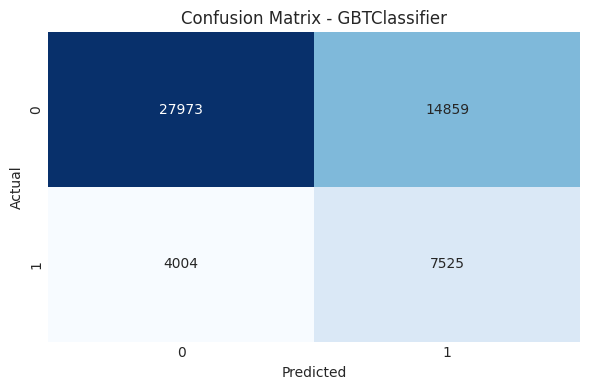

In [9]:
best_model_name = comparison_pdf.loc[0, "model"]
best_predictions = prediction_cache[best_model_name]

print(f"Best model by AUC: {best_model_name}")
best_predictions.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

cm_pdf = (
    best_predictions
    .groupBy(F.col("label").cast("int").alias("label"), F.col("prediction").cast("int").alias("prediction"))
    .count()
    .toPandas()
)

cm_matrix = (
    cm_pdf
    .pivot(index="label", columns="prediction", values="count")
    .reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    .fillna(0)
    .astype(int)
)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

26/05/13 10:56:53 WARN DAGScheduler: Broadcasting large task binary with size 1724.0 KiB


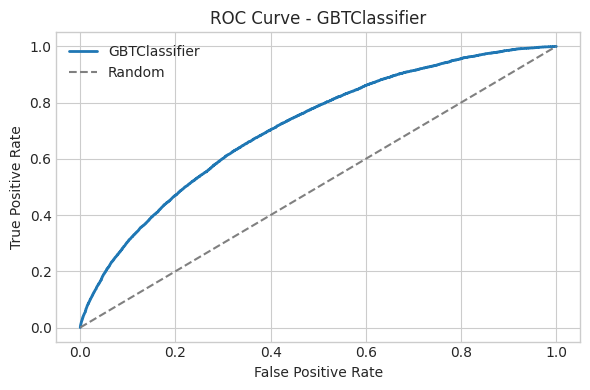

In [10]:
score_udf = F.udf(lambda v: float(v[1]) if v is not None else None, DoubleType())
score_source_col = "probability" if "probability" in best_predictions.columns else "rawPrediction"

roc_points_pdf = (
    best_predictions
    .select(
        F.col("label").cast("int").alias("label"),
        score_udf(F.col(score_source_col)).alias("score"),
    )
    .dropna()
    .toPandas()
)

fpr, tpr, thresholds = roc_curve(roc_points_pdf["label"], roc_points_pdf["score"])
roc_pdf = pd.DataFrame({"fpr": fpr, "tpr": tpr, "threshold": thresholds})

plt.figure(figsize=(6, 4))
plt.plot(roc_pdf["fpr"], roc_pdf["tpr"], label=best_model_name, linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.title(f"ROC Curve - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

Threshold tuning (top 10 by lowest expected cost):
        model  threshold    tn    fp   fn    tp  accuracy  precision   recall       f1  expected_cost  fp_cost  fn_cost
GBTClassifier       0.40 19754 23078 2098  9431  0.536874   0.290104 0.818024 0.428312        33568.0      1.0      5.0
GBTClassifier       0.45 23874 18958 2975  8554  0.596531   0.310919 0.741955 0.438206        33833.0      1.0      5.0
GBTClassifier       0.35 15918 26914 1397 10132  0.479204   0.273498 0.878827 0.417169        33899.0      1.0      5.0
GBTClassifier       0.50 27973 14859 4004  7525  0.653005   0.336178 0.652702 0.443783        34879.0      1.0      5.0
GBTClassifier       0.30 12322 30510  931 10598  0.421626   0.257809 0.919247 0.402683        35165.0      1.0      5.0
GBTClassifier       0.25  9104 33728  563 10966  0.369199   0.245357 0.951167 0.390089        36543.0      1.0      5.0
GBTClassifier       0.55 31746 11086 5216  6313  0.700116   0.362837 0.547576 0.436463        37166.0      1.

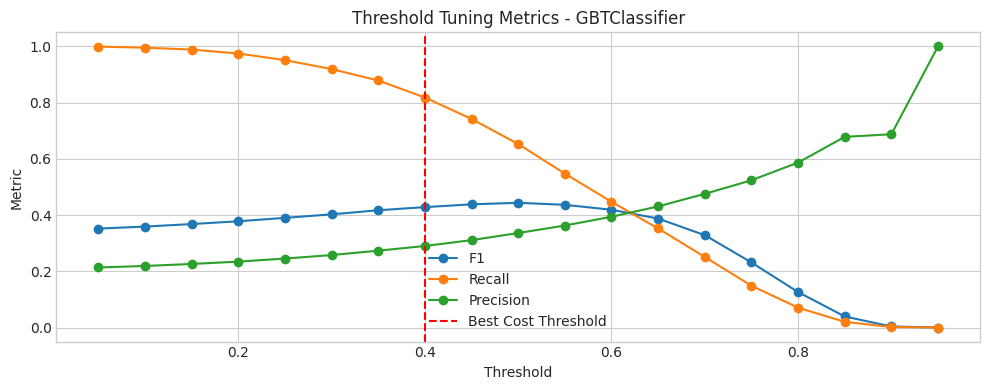

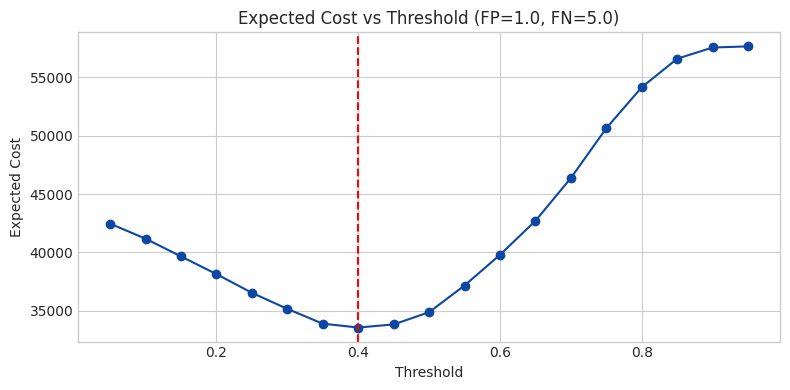

,model,fp_cost,fn_cost,optimal_threshold,minimum_expected_cost,f1_at_optimal,recall_at_optimal,precision_at_optimal
0,GBTClassifier,1.0,3.0,0.55,26734.0,0.436463,0.547576,0.362837
1,GBTClassifier,1.0,5.0,0.40,33568.0,0.428312,0.818024,0.290104
2,GBTClassifier,2.0,5.0,0.60,47721.0,0.418966,0.447220,0.394069
3,GBTClassifier,1.0,8.0,0.30,37958.0,0.402683,0.919247,0.257809
4,GBTClassifier,3.0,10.0,0.50,84617.0,0.443783,0.652702,0.336178


In [11]:
score_series = roc_points_pdf["score"].astype(float)
score_min = float(score_series.min())
score_max = float(score_series.max())

if score_min < 0.0 or score_max > 1.0:
    # Convert margin-like scores to pseudo-probabilities for threshold search.
    calibrated_scores = 1.0 / (1.0 + np.exp(-score_series))
else:
    calibrated_scores = score_series

thresholds_to_test = np.round(np.linspace(0.05, 0.95, 19), 2)
fp_cost_base = float(os.getenv("STEP6_FP_COST", "1.0"))
fn_cost_base = float(os.getenv("STEP6_FN_COST", "5.0"))

threshold_rows = []
for threshold_value in thresholds_to_test:
    pred = (calibrated_scores >= threshold_value).astype(int)
    actual = roc_points_pdf["label"].astype(int)

    tn = int(((actual == 0) & (pred == 0)).sum())
    fp = int(((actual == 0) & (pred == 1)).sum())
    fn = int(((actual == 1) & (pred == 0)).sum())
    tp = int(((actual == 1) & (pred == 1)).sum())

    total = tn + fp + fn + tp
    accuracy = (tn + tp) / total if total else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0.0
    expected_cost = (fp * fp_cost_base) + (fn * fn_cost_base)

    threshold_rows.append({
        "model": best_model_name,
        "threshold": float(threshold_value),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "expected_cost": float(expected_cost),
        "fp_cost": float(fp_cost_base),
        "fn_cost": float(fn_cost_base),
    })

threshold_tuning_pdf = pd.DataFrame(threshold_rows).sort_values("threshold").reset_index(drop=True)
optimal_threshold_by_cost = threshold_tuning_pdf.sort_values(["expected_cost", "f1"], ascending=[True, False]).iloc[0]
optimal_threshold_by_f1 = threshold_tuning_pdf.sort_values("f1", ascending=False).iloc[0]

cost_scenarios = [
    (1.0, 3.0),
    (1.0, 5.0),
    (1.0, 8.0),
    (2.0, 5.0),
    (3.0, 10.0),
]

scenario_rows = []
for scenario_fp_cost, scenario_fn_cost in cost_scenarios:
    scenario_eval = threshold_tuning_pdf.copy()
    scenario_eval["expected_cost"] = (
        scenario_eval["fp"] * scenario_fp_cost + scenario_eval["fn"] * scenario_fn_cost
    )
    scenario_best = scenario_eval.sort_values(["expected_cost", "f1"], ascending=[True, False]).iloc[0]
    scenario_rows.append({
        "model": best_model_name,
        "fp_cost": float(scenario_fp_cost),
        "fn_cost": float(scenario_fn_cost),
        "optimal_threshold": float(scenario_best["threshold"]),
        "minimum_expected_cost": float(scenario_best["expected_cost"]),
        "f1_at_optimal": float(scenario_best["f1"]),
        "recall_at_optimal": float(scenario_best["recall"]),
        "precision_at_optimal": float(scenario_best["precision"]),
    })

business_cost_matrix_pdf = pd.DataFrame(scenario_rows).sort_values(["fn_cost", "fp_cost"]).reset_index(drop=True)

print("Threshold tuning (top 10 by lowest expected cost):")
print(threshold_tuning_pdf.sort_values(["expected_cost", "f1"], ascending=[True, False]).head(10).to_string(index=False))
print("\nBest threshold by expected cost:")
print(optimal_threshold_by_cost.to_string())
print("\nBest threshold by F1:")
print(optimal_threshold_by_f1.to_string())

plt.figure(figsize=(10, 4))
plt.plot(threshold_tuning_pdf["threshold"], threshold_tuning_pdf["f1"], marker="o", label="F1")
plt.plot(threshold_tuning_pdf["threshold"], threshold_tuning_pdf["recall"], marker="o", label="Recall")
plt.plot(threshold_tuning_pdf["threshold"], threshold_tuning_pdf["precision"], marker="o", label="Precision")
plt.axvline(float(optimal_threshold_by_cost["threshold"]), linestyle="--", color="red", label="Best Cost Threshold")
plt.title(f"Threshold Tuning Metrics - {best_model_name}")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(threshold_tuning_pdf["threshold"], threshold_tuning_pdf["expected_cost"], marker="o", color="#0d47a1")
plt.axvline(float(optimal_threshold_by_cost["threshold"]), linestyle="--", color="red")
plt.title(f"Expected Cost vs Threshold (FP={fp_cost_base}, FN={fn_cost_base})")
plt.xlabel("Threshold")
plt.ylabel("Expected Cost")
plt.tight_layout()
plt.show()

business_cost_matrix_pdf

Feature importance generated for LogisticRegression (absolute_coefficients).
Feature importance generated for DecisionTreeClassifier (tree_feature_importance).
Feature importance generated for RandomForestClassifier (tree_feature_importance).


Feature importance generated for GBTClassifier (tree_feature_importance).
Feature importance generated for LinearSVC (absolute_coefficients).


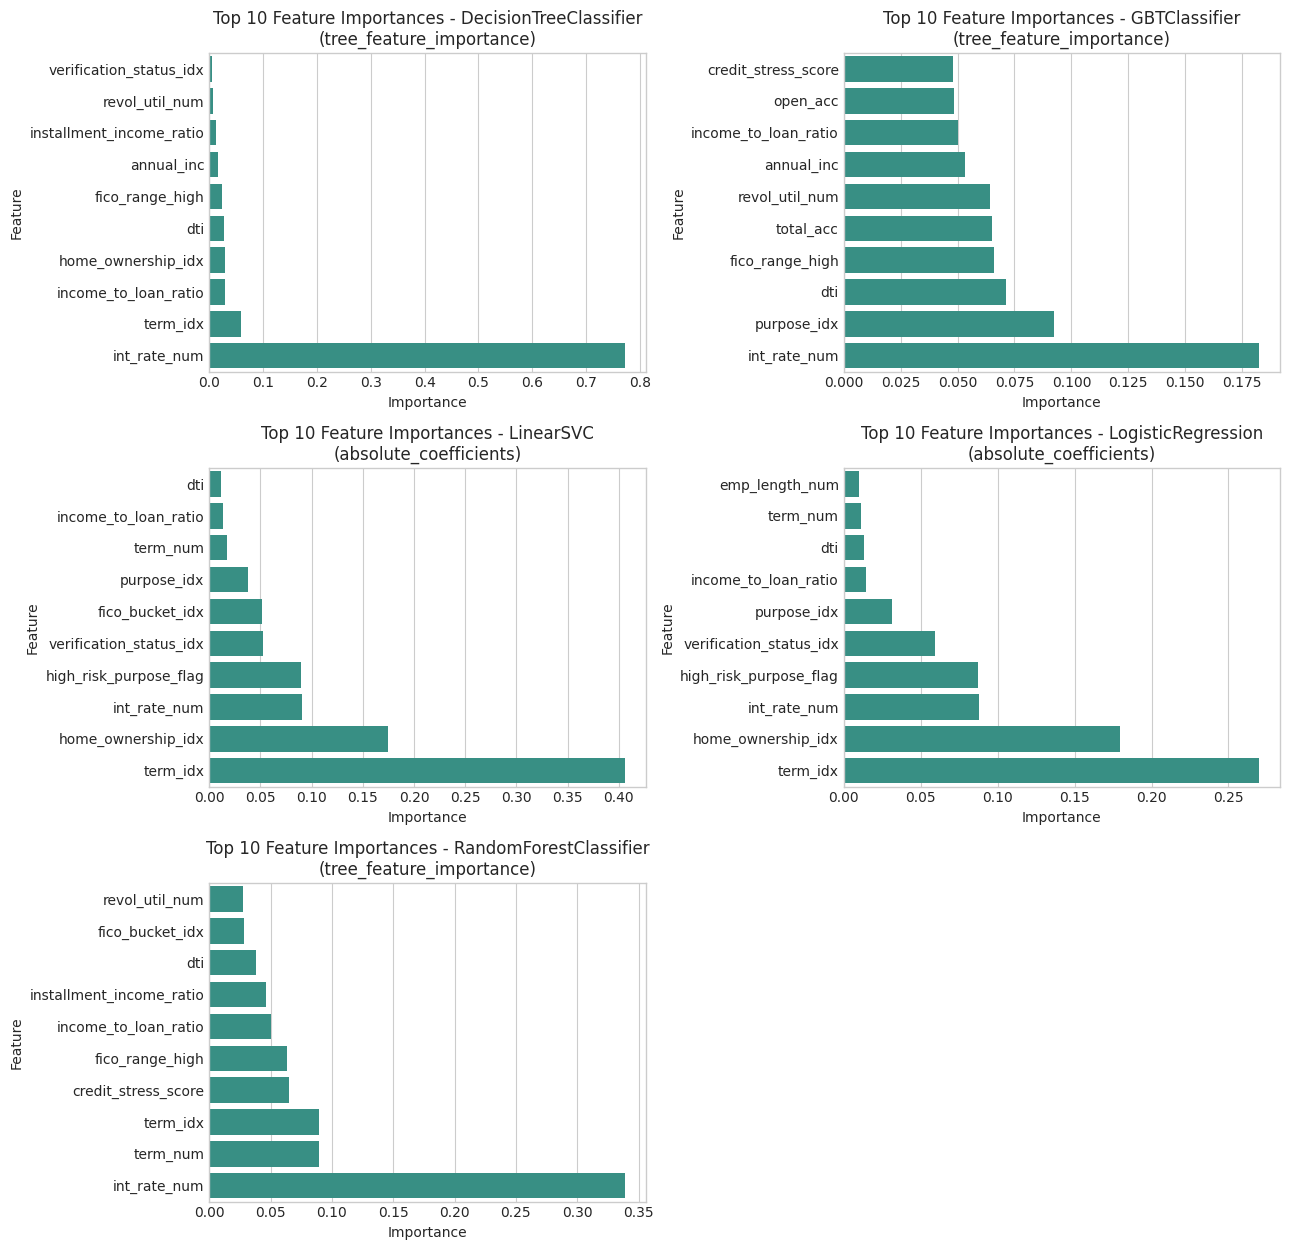

In [12]:
model_importance_outputs = {}

def _vector_to_numpy(vector_like):
    if vector_like is None:
        return None
    if hasattr(vector_like, "toArray"):
        return np.array(vector_like.toArray(), dtype=float)
    try:
        return np.array(vector_like, dtype=float)
    except Exception:
        return None

for model_name, fitted_model in trained_models.items():
    importances = None
    importance_method = None

    if hasattr(fitted_model, "featureImportances") and fitted_model.featureImportances is not None:
        importances = _vector_to_numpy(fitted_model.featureImportances)
        importance_method = "tree_feature_importance"
    elif hasattr(fitted_model, "coefficients") and fitted_model.coefficients is not None:
        coef_values = _vector_to_numpy(fitted_model.coefficients)
        if coef_values is not None:
            importances = np.abs(coef_values)
            importance_method = "absolute_coefficients"
    elif hasattr(fitted_model, "coefficientMatrix") and fitted_model.coefficientMatrix is not None:
        coef_matrix = _vector_to_numpy(fitted_model.coefficientMatrix)
        if coef_matrix is not None and coef_matrix.ndim == 2:
            importances = np.mean(np.abs(coef_matrix), axis=0)
            importance_method = "mean_absolute_coefficients"

    if importances is None or len(importances) == 0:
        print(f"Skipping feature importance for {model_name}: no compatible importance signal.")
        continue

    if len(importances) != len(numeric_cols):
        min_len = min(len(importances), len(numeric_cols))
        print(
            f"Warning: {model_name} importance length mismatch (model={len(importances)}, features={len(numeric_cols)}). "
            f"Using first {min_len} values."
        )
        feature_names = numeric_cols[:min_len]
        importances = importances[:min_len]
    else:
        feature_names = numeric_cols

    importance_pdf = pd.DataFrame({
        "feature": feature_names,
        "importance": pd.to_numeric(importances, errors="coerce"),
    }).dropna(subset=["importance"])

    if importance_pdf.empty:
        print(f"Skipping feature importance for {model_name}: empty importance table after cleanup.")
        continue

    importance_pdf["importance"] = importance_pdf["importance"].astype(float).clip(lower=0.0)
    importance_sum = float(importance_pdf["importance"].sum())
    importance_pdf["importance_norm"] = (
        importance_pdf["importance"] / importance_sum if importance_sum > 0 else 0.0
    )
    importance_pdf = importance_pdf.sort_values("importance", ascending=False).reset_index(drop=True)
    importance_pdf["rank"] = np.arange(1, len(importance_pdf) + 1)
    importance_pdf["model"] = model_name
    importance_pdf["importance_method"] = importance_method

    model_importance_outputs[model_name] = importance_pdf
    print(f"Feature importance generated for {model_name} ({importance_method}).")

rf_importance_pdf = model_importance_outputs.get("RandomForestClassifier", pd.DataFrame())
gbt_importance_pdf = model_importance_outputs.get("GBTClassifier", pd.DataFrame())

if model_importance_outputs:
    model_names_for_plot = sorted(model_importance_outputs.keys())
    n_models = len(model_names_for_plot)
    n_cols = 2
    n_rows = int(np.ceil(n_models / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4.2 * n_rows))
    axes = np.atleast_1d(axes).reshape(-1)

    for idx, model_name in enumerate(model_names_for_plot):
        ax = axes[idx]
        top_features = model_importance_outputs[model_name].head(10).sort_values("importance", ascending=True)
        sns.barplot(data=top_features, x="importance", y="feature", orient="h", ax=ax, color="#2a9d8f")
        method = top_features["importance_method"].iloc[0] if not top_features.empty else "n/a"
        ax.set_title(f"Top 10 Feature Importances - {model_name}\n({method})")
        ax.set_xlabel("Importance")
        ax.set_ylabel("Feature")

    for idx in range(n_models, len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No feature importance output generated for the trained models.")

In [13]:
output_dir = Path(WORKSPACE_ROOT) / "output" / "step6"
output_dir.mkdir(parents=True, exist_ok=True)

comparison_pdf.to_csv(output_dir / "model_comparison.csv", index=False)
cm_pdf.to_csv(output_dir / "confusion_matrix_best.csv", index=False)
roc_pdf.to_csv(output_dir / "roc_curve_best.csv", index=False)
threshold_tuning_pdf.to_csv(output_dir / "threshold_tuning_best_model.csv", index=False)
business_cost_matrix_pdf.to_csv(output_dir / "business_cost_matrix.csv", index=False)

for model_name, importance_pdf in model_importance_outputs.items():
    if importance_pdf.empty:
        continue
    safe_model_name = "".join(ch.lower() if ch.isalnum() else "_" for ch in model_name).strip("_")
    importance_pdf.to_csv(output_dir / f"feature_importance_{safe_model_name}.csv", index=False)

# Backward-compatible exports for dashboard files used in app.py.
if "RandomForestClassifier" in model_importance_outputs:
    model_importance_outputs["RandomForestClassifier"].to_csv(output_dir / "feature_importance_rf.csv", index=False)
if "GBTClassifier" in model_importance_outputs:
    model_importance_outputs["GBTClassifier"].to_csv(output_dir / "feature_importance_gbt.csv", index=False)

default_rate = float(df.select(F.avg(F.col("label"))).first()[0])
avg_interest_rate = None
if "int_rate_num" in df.columns:
    avg_interest_rate = float(df.select(F.avg(F.col("int_rate_num"))).first()[0])

executive_metrics = {
    "total_loans": int(df.count()),
    "default_rate": default_rate,
    "best_model": best_model_name,
    "best_auc": float(comparison_pdf.loc[0, "auc"]),
    "avg_interest_rate": avg_interest_rate,
    "recommended_threshold_cost": float(optimal_threshold_by_cost["threshold"]),
    "recommended_threshold_f1": float(optimal_threshold_by_f1["threshold"]),
    "fp_cost_base": float(fp_cost_base),
    "fn_cost_base": float(fn_cost_base),
}

with open(output_dir / "executive_metrics.json", "w", encoding="utf-8") as f:
    json.dump(executive_metrics, f, indent=2)

threshold_summary = {
    "model": best_model_name,
    "score_min": score_min,
    "score_max": score_max,
    "uses_sigmoid_calibration": bool(score_min < 0.0 or score_max > 1.0),
    "best_threshold_by_cost": float(optimal_threshold_by_cost["threshold"]),
    "best_threshold_by_f1": float(optimal_threshold_by_f1["threshold"]),
    "f1_at_best_cost": float(optimal_threshold_by_cost["f1"]),
    "recall_at_best_cost": float(optimal_threshold_by_cost["recall"]),
    "precision_at_best_cost": float(optimal_threshold_by_cost["precision"]),
    "expected_cost_at_best_cost": float(optimal_threshold_by_cost["expected_cost"]),
}

with open(output_dir / "threshold_summary.json", "w", encoding="utf-8") as f:
    json.dump(threshold_summary, f, indent=2)

print(f"Step 6 artifacts exported to: {output_dir.as_posix()}")
print("Generated files:")
for file_name in sorted(os.listdir(output_dir)):
    print(f"- {file_name}")

Step 6 artifacts exported to: c:/Users/MONSTER/Desktop/fintech-credit-risk-engine-main/output/step6
Generated files:
- business_cost_matrix.csv
- confusion_matrix_best.csv
- executive_metrics.json
- feature_importance_decisiontreeclassifier.csv
- feature_importance_gbt.csv
- feature_importance_gbtclassifier.csv
- feature_importance_linearsvc.csv
- feature_importance_logisticregression.csv
- feature_importance_randomforestclassifier.csv
- feature_importance_rf.csv
- model_comparison.csv
- roc_curve_best.csv
- threshold_summary.json
- threshold_tuning_best_model.csv


## Step 6 Summary

This notebook satisfies the Step 6 requirements:
- Delta Gold feature table is loaded in Spark.
- 5 classification models are trained and compared.
- Accuracy, F1, Precision, Recall, and AUC are produced.
- MLflow logs params, metrics, and model artifacts for each run.
- Feature importance is generated for all trained models.
- Model-specific feature importance files are exported as feature_importance_modeladi.csv (for example, feature_importance_logisticregression.csv).
- Backward-compatible files feature_importance_rf.csv and feature_importance_gbt.csv are also exported for dashboard integration.
- Threshold tuning and business cost matrix are generated for decision optimization.